# PART 1: Wikidata Editor Network Analysis

This notebook covers **Task A** (Network Construction), **Task B** (Network Metrics), and **Task C** (Epidemic Models) for three Wikidata talk page datasets of different sizes:

| Size | Dataset |
|------|---------|
| Large | `REQUEST_FOR_DELETION` |
| Medium | `USERS` |
| Small | `BOT_REQUESTS` |

Dataset size was determined by file size: BOT_REQUESTS (258 KB, small), USERS (10,149 KB, medium), REQUEST_FOR_DELETION (47,294 KB, large).
Each dataset is a CSV with three columns: thread_subject, username, page_name and each row records a comment made by a user in a specific thread of a specific page.

## 0. Setup & Imports

In [2]:
import pandas as pd
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import collections
import random
import warnings
from itertools import combinations
from scipy import stats

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

DATASETS = {
    'BOT_REQUESTS'        : 'BOT_REQUESTS.csv',          # small
    'USERS'               : 'USERS.csv',                 # medium
    'REQUEST_FOR_DELETION': 'REQUEST_FOR_DELETION.csv',  # large
}

COLORS = {
    'BOT_REQUESTS'        : '#2196F3',
    'USERS'               : '#4CAF50',
    'REQUEST_FOR_DELETION': '#F44336',
}

## TASK A : Network Construction

### A.1 What elements are represented as nodes and edges?

**Nodes** represent individual Wikidata editors, uniquely identified by their username. Each unique username in the dataset becomes one node, assigned an integer ID for graph storage. Additional metadata (total comment count) is stored as a node attribute.

**Edges** represent a social connection between two editors. Two editors share an undirected, weighted edge if they **both posted at least one comment in the same thread on the same page**. This captures the opportunity for direct interaction. **Edge weight** records how many distinct (page, thread) pairs the two editors co-appeared in, quantifying tie strength.

Information that cannot be directly encoded as graph topology such as the raw comment text, timestamps, or which specific pages a user posted on is retained in the original `pandas.DataFrame` and in node attributes (e.g. `comment_count`).

### A.2 What data structures were chosen?

- `pandas.DataFrame` - for loading, cleaning, and grouping the raw CSV data
- `dict` (username -> integer node ID) - for O(1) lookup when assigning edges; stored in `G.graph['user_to_id']`
- `collections.Counter` - for efficiently accumulating edge weights during the groupby pass
- `networkx.Graph` - undirected weighted graph; chosen over DiGraph because the co-commenting relationship is symmetric (if A and B both comment in the same thread, the connection goes both ways equally)

### A.3 Algorithmic approach

1. Load CSV and normalise column names and whitespace
2. Assign a unique integer ID to each unique username (sorted for reproducibility)
3. Group all rows by `(page_name, thread_subject)` - each group is one discussion thread
4. For each thread, take all distinct users who participated and generate every pair using `itertools.combinations`
5. Accumulate pair counts in a `Counter` (this becomes edge weight)
6. Add all weighted edges to the NetworkX graph in a single pass
7. Attach node attributes (username, comment_count) and graph-level metadata

This approach is generic, meaning changing the grouping key (e.g. grouping only by `page_name`, ignoring threads) immediately produces a different, coarser network definition.


In [3]:
def load_dataset(path):
    df = pd.read_csv(path)
    df.columns = [c.strip().lower() for c in df.columns]
    # Standardising column names regardless of minor spelling differences
    rename = {}
    for col in df.columns:
        if 'thread' in col:  rename[col] = 'thread_subject'
        elif 'user' in col:  rename[col] = 'username'
        elif 'page' in col:  rename[col] = 'page_name'
    df = df.rename(columns=rename)
    df = df.dropna(subset=['username', 'thread_subject', 'page_name'])
    df['username']       = df['username'].str.strip()
    df['thread_subject'] = df['thread_subject'].str.strip()
    df['page_name']      = df['page_name'].str.strip()
    return df


def build_network(df, dataset_name):
    G = nx.Graph(name=dataset_name)

    # Step 1: assign integer node IDs 
    users = sorted(df['username'].unique())
    user_to_id = {u: i for i, u in enumerate(users)}
    G.add_nodes_from(range(len(users)))
    nx.set_node_attributes(G, {i: u for u, i in user_to_id.items()}, 'username')

    # Counting total comments per user (kept as node attribute)
    comment_counts = df['username'].value_counts().to_dict()
    nx.set_node_attributes(G, {user_to_id[u]: c for u, c in comment_counts.items()}, 'comment_count')

    # Step 2: group by (page, thread) and add edges
    # For each (page, thread) pair, every pair of distinct users who posted there gets an edge (or their existing edge weight incremented).
    edge_weights = collections.Counter()
    grouped = df.groupby(['page_name', 'thread_subject'])['username'].apply(list)

    for participants in grouped:
        unique_users = list(set(participants))
        for u1, u2 in combinations(unique_users, 2):
            i, j = user_to_id[u1], user_to_id[u2]
            key = (min(i,j), max(i,j))
            edge_weights[key] += 1

    # Adding weighted edges to graph
    for (i, j), w in edge_weights.items():
        G.add_edge(i, j, weight=w)

    # Store metadata
    G.graph['num_raw_rows']     = len(df)
    G.graph['num_unique_users'] = len(users)
    G.graph['num_pages']        = df['page_name'].nunique()
    G.graph['num_threads']      = df.groupby(['page_name','thread_subject']).ngroups
    G.graph['user_to_id']       = user_to_id

    return G

In [4]:
# Load all three datasets and build networks
dataframes = {}
graphs     = {}

for name, path in DATASETS.items():
    print(f' {name} ')
    df = load_dataset(path)
    dataframes[name] = df
    G  = build_network(df, name)
    graphs[name] = G
    print(f'  Rows: {G.graph["num_raw_rows"]:,} | Users: {G.graph["num_unique_users"]:,}'
          f' | Pages: {G.graph["num_pages"]:,} | Threads: {G.graph["num_threads"]:,}')
    print(f'  Nodes: {G.number_of_nodes():,} | Edges: {G.number_of_edges():,}')
    print()

 BOT_REQUESTS 
  Rows: 2,985 | Users: 552 | Pages: 108 | Threads: 1,127
  Nodes: 552 | Edges: 2,425

 USERS 
  Rows: 171,692 | Users: 11,387 | Pages: 65,076 | Threads: 142,384
  Nodes: 11,387 | Edges: 24,755

 REQUEST_FOR_DELETION 
  Rows: 648,644 | Users: 9,935 | Pages: 3,303 | Threads: 318,883
  Nodes: 9,935 | Edges: 33,497



In [5]:
# Network summary table
summary_rows = []
for name, G in graphs.items():
    summary_rows.append({
        'Dataset'    : name,
        'Nodes (N)'  : G.number_of_nodes(),
        'Edges (E)'  : G.number_of_edges(),
        'Raw Rows'   : G.graph['num_raw_rows'],
        'Pages'      : G.graph['num_pages'],
        'Threads'    : G.graph['num_threads'],
    })

summary_df = pd.DataFrame(summary_rows).set_index('Dataset')
print('Network Construction Summary: ')
print(summary_df.to_string())

Network Construction Summary: 
                      Nodes (N)  Edges (E)  Raw Rows  Pages  Threads
Dataset                                                             
BOT_REQUESTS                552       2425      2985    108     1127
USERS                     11387      24755    171692  65076   142384
REQUEST_FOR_DELETION       9935      33497    648644   3303   318883


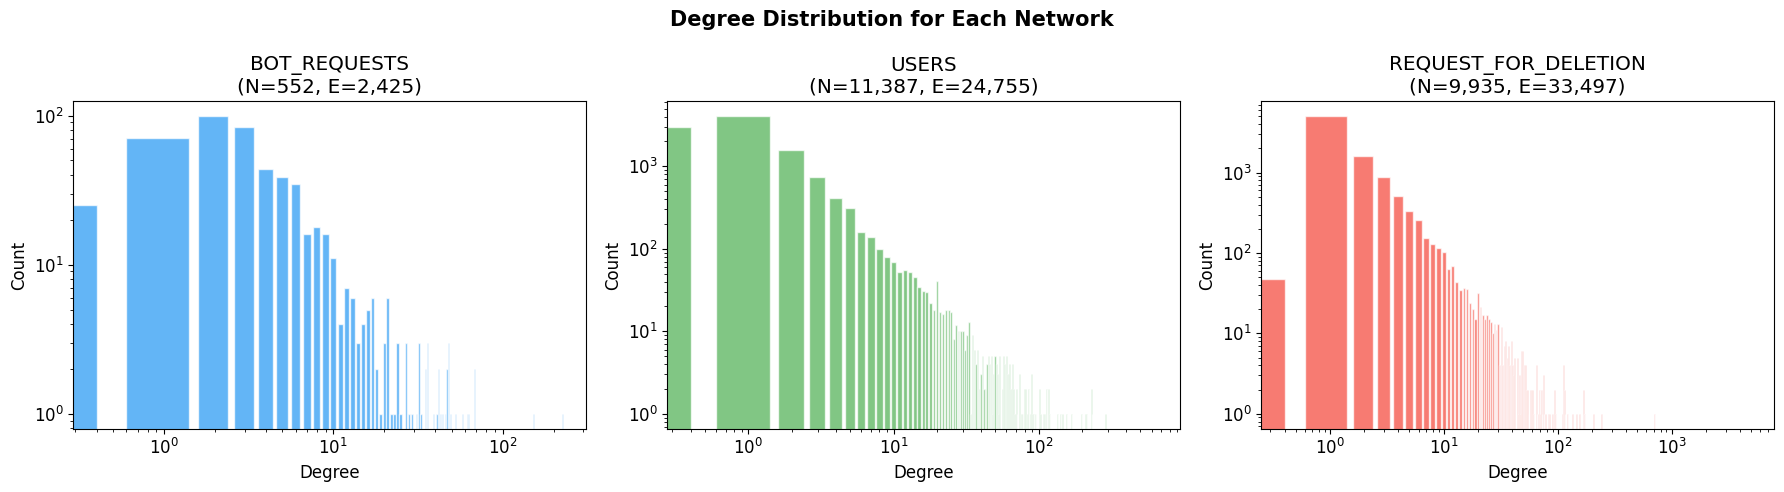

In [6]:
# Degree Distribution Visualisation
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Degree Distribution for Each Network', fontsize=15, fontweight='bold')

for ax, (name, G) in zip(axes, graphs.items()):
    degrees = [d for _, d in G.degree()]
    degree_counts = collections.Counter(degrees)
    deg_vals  = sorted(degree_counts.keys())
    deg_freqs = [degree_counts[d] for d in deg_vals]

    ax.bar(deg_vals, deg_freqs, color=COLORS[name], alpha=0.7, edgecolor='white')
    ax.set_title(f'{name}\n(N={G.number_of_nodes():,}, E={G.number_of_edges():,})')
    ax.set_xlabel('Degree')
    ax.set_ylabel('Count')
    ax.set_yscale('log')
    ax.set_xscale('log')

plt.tight_layout()
plt.savefig('task_a_degree_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

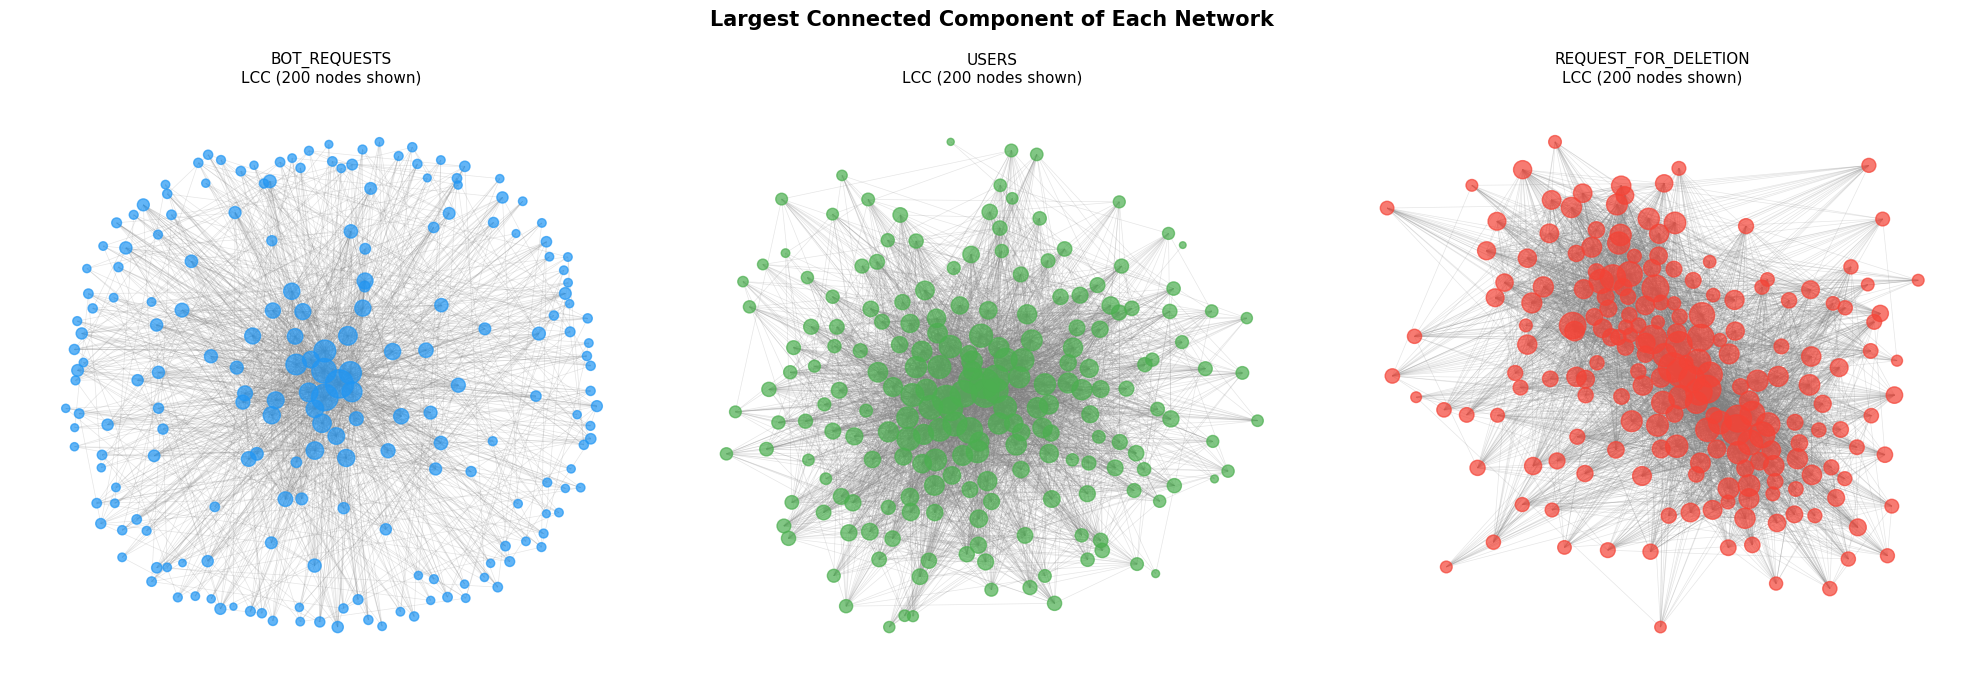

In [7]:
# Network Visualisation (Largest Connected Component)
def draw_lcc(G, name, ax, color, max_nodes=200):
    lcc = max(nx.connected_components(G), key=len)
    subG = G.subgraph(lcc).copy()

    # Sampling if too large to visualise clearly
    if subG.number_of_nodes() > max_nodes:
        degrees = dict(subG.degree())
        sampled = sorted(degrees, key=degrees.get, reverse=True)[:max_nodes]
        subG = subG.subgraph(sampled).copy()

    pos = nx.spring_layout(subG, seed=42, k=1.5)
    degrees = dict(subG.degree())
    node_sizes = [20 + degrees[n]*3 for n in subG.nodes()]

    nx.draw_networkx_nodes(subG, pos, ax=ax, node_size=node_sizes,
                           node_color=color, alpha=0.7)
    nx.draw_networkx_edges(subG, pos, ax=ax, alpha=0.2, edge_color='gray', width=0.5)
    ax.set_title(f'{name}\nLCC ({subG.number_of_nodes()} nodes shown)', fontsize=11)
    ax.axis('off')

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('Largest Connected Component of Each Network', fontsize=15, fontweight='bold')

for ax, (name, G) in zip(axes, graphs.items()):
    draw_lcc(G, name, ax, COLORS[name])

plt.tight_layout()
plt.savefig('task_a_network_visualisation.png', dpi=150, bbox_inches='tight')
plt.show()

## TASK B : Network Metrics

We analyse each network across three dimensions: (1) basic structural properties, (2) comparison against an equivalent Erdős-Rényi random graph, and (3) centrality of individual editors.

The key question is: **where do these networks sit on the regular - small world - random network spectrum?**

A small world network is characterised by two hallmarks compared to a random graph with the same N and E:
- **Much higher clustering coefficient** (C_real >> C_random)
- **Similar or shorter average path length** (L_real ≈ L_random or shorter)

The Watts-Strogatz sigma metric σ = (C_real/C_random) / (L_real/L_random) quantifies this: **σ > 1 indicates small world behaviour**.

| Metric | Interpretation |
|--------|-------------------------------|
| Density | Fraction of all possible editor pairs who share a thread |
| Avg Degree | Average number of distinct co-commenters per editor |
| Heterogeneity (σ/μ) | How unequal is participation, High = a few editors dominate |
| Avg Clustering | Do an editor's connections also know each other |
| Avg Path Length | How many hops to reach any other editor |
| Assortativity | Do prolific editors tend to connect with other prolific editors |


In [8]:
def compute_metrics(G, name, sample_size=2000):
    N = G.number_of_nodes()
    E = G.number_of_edges()
    degrees = [d for _, d in G.degree()]

    # Basic
    density      = nx.density(G)
    avg_degree   = np.mean(degrees)
    std_degree   = np.std(degrees)
    max_degree   = max(degrees)
    heterogeneity = std_degree / avg_degree if avg_degree > 0 else 0

    # Clustering
    avg_clustering = nx.average_clustering(G)

    # Connected components
    components = list(nx.connected_components(G))
    n_components = len(components)
    lcc = max(components, key=len)
    lcc_fraction = len(lcc) / N

    # Shortest paths on LCC (sampled for large networks)
    lcc_G = G.subgraph(lcc).copy()
    if len(lcc) > sample_size:
        sample_nodes = random.sample(list(lcc), sample_size)
        path_lengths = []
        for src in sample_nodes[:200]:  
            lengths = nx.single_source_shortest_path_length(lcc_G, src)
            path_lengths.extend(lengths.values())
        avg_path   = np.mean([l for l in path_lengths if l > 0])
        diameter   = 'N/A (sampled)'
    else:
        all_lengths = dict(nx.all_pairs_shortest_path_length(lcc_G))
        flat = [l for s in all_lengths.values() for l in s.values() if l > 0]
        avg_path = np.mean(flat)
        diameter = nx.diameter(lcc_G)

    # Assortativity
    try:
        assortativity = nx.degree_assortativity_coefficient(G)
    except Exception:
        assortativity = float('nan')

    return {
        'Dataset'               : name,
        'N (nodes)'             : N,
        'E (edges)'             : E,
        'Density'               : round(density, 6),
        'Avg Degree'            : round(avg_degree, 3),
        'Max Degree'            : max_degree,
        'Degree Std'            : round(std_degree, 3),
        'Heterogeneity (σ/μ)'   : round(heterogeneity, 3),
        'Avg Clustering'        : round(avg_clustering, 4),
        'Avg Path Length (LCC)' : round(avg_path, 3),
        'Diameter (LCC)'        : diameter,
        'Num Components'        : n_components,
        'LCC Fraction'          : round(lcc_fraction, 4),
        'Assortativity'         : round(assortativity, 4),
    }

all_metrics = []
for name, G in graphs.items():
    m = compute_metrics(G, name)
    all_metrics.append(m)

metrics_df = pd.DataFrame(all_metrics).set_index('Dataset')
print('\nNetwork Metrics: ' )
print(metrics_df.T.to_string())


Network Metrics: 
Dataset               BOT_REQUESTS          USERS REQUEST_FOR_DELETION
N (nodes)                      552          11387                 9935
E (edges)                     2425          24755                33497
Density                   0.015946       0.000382             0.000679
Avg Degree                   8.786          4.348                6.743
Max Degree                     226            649                 4940
Degree Std                  18.623         18.808               72.061
Heterogeneity (σ/μ)           2.12          4.326               10.686
Avg Clustering              0.6576         0.1834                0.392
Avg Path Length (LCC)        2.603          3.654                2.697
Diameter (LCC)                   6  N/A (sampled)        N/A (sampled)
Num Components                  29           3255                   57
LCC Fraction                0.9402         0.6827               0.9935
Assortativity              -0.2785         -0.151         

### B.1 Comparison with Erdős-Rényi Random Graphs

For each real network, we generate 3 Erdős-Rényi (ER) random graphs with the **same number of nodes N and same edge probability p = 2E / N(N-1)**. We then compare clustering coefficient C and average path length L.

**Key insight:** In a random graph, C_random ≈ p (very low for sparse graphs), while L_random ≈ ln(N)/ln(⟨k⟩) (short due to randomness). A real world network that has C >> C_random but L ≈ L_random or shorter is a **small world network**.

**Interpretation:**
- All three networks show clustering coefficients **42× to 766× higher** than equivalent random graphs
- All three networks show average path lengths **shorter** than their random equivalents (L_real/L_random < 1)
- The Watts-Strogatz σ values of **51 (BOT_REQUESTS), 1372 (USERS), and 1304 (REQUEST_FOR_DELETION)**, all vastly greater than 1 that confirms all three are **strongly small world networks**
- The negative assortativity in all three networks (ranging from -0.15 to -0.28) indicates that high-degree hubs tend to connect to low-degree peripheral editors which is a common feature of real world communication networks

These results suggest that Wikidata editors form tight-knit local communities around specific topics or tasks, while a small number of highly active editors act as bridges connecting otherwise separate discussion groups across the platform.


In [9]:
def random_graph_comparison(G, name, n_trials=5):
    N = G.number_of_nodes()
    E = G.number_of_edges()
    p = (2 * E) / (N * (N - 1)) if N > 1 else 0

    rand_clustering = []
    rand_path       = []

    for _ in range(n_trials):
        R = nx.erdos_renyi_graph(N, p, seed=42 + _)
        rand_clustering.append(nx.average_clustering(R))
        # Path length on LCC of random graph
        lcc_r = max(nx.connected_components(R), key=len)
        lcc_G_r = R.subgraph(lcc_r).copy()
        if len(lcc_r) > 500:
            srcs = random.sample(list(lcc_r), 100)
            paths = []
            for s in srcs:
                paths.extend(nx.single_source_shortest_path_length(lcc_G_r, s).values())
            rand_path.append(np.mean([x for x in paths if x > 0]))
        else:
            all_l = dict(nx.all_pairs_shortest_path_length(lcc_G_r))
            flat  = [l for s in all_l.values() for l in s.values() if l > 0]
            rand_path.append(np.mean(flat))

    # Real network values
    real_clustering = nx.average_clustering(G)
    lcc = max(nx.connected_components(G), key=len)
    lcc_G = G.subgraph(lcc).copy()
    if len(lcc) > 2000:
        srcs = random.sample(list(lcc), 200)
        paths = []
        for s in srcs:
            paths.extend(nx.single_source_shortest_path_length(lcc_G, s).values())
        real_path = np.mean([x for x in paths if x > 0])
    else:
        all_l = dict(nx.all_pairs_shortest_path_length(lcc_G))
        flat  = [l for s in all_l.values() for l in s.values() if l > 0]
        real_path = np.mean(flat)

    sigma_C = real_clustering / np.mean(rand_clustering) if np.mean(rand_clustering) > 0 else float('inf')
    sigma_L = real_path       / np.mean(rand_path)       if np.mean(rand_path) > 0       else float('inf')
    small_world_sigma = sigma_C / sigma_L  # Watts-Strogatz sigma > 1 -> small world

    return {
        'Dataset'              : name,
        'Real C'               : round(real_clustering, 5),
        'ER Avg C'             : round(np.mean(rand_clustering), 5),
        'C_real / C_random'    : round(sigma_C, 2),
        'Real L (LCC)'         : round(real_path, 3),
        'ER Avg L'             : round(np.mean(rand_path), 3),
        'L_real / L_random'    : round(sigma_L, 3),
        'Small World σ (C/L ratio)': round(small_world_sigma, 3),
        'Verdict'              : 'Small World' if small_world_sigma > 1 else 'Random like',
    }

rg_rows = []
for name, G in graphs.items():
    rg_rows.append(random_graph_comparison(G, name, n_trials=3))

rg_df = pd.DataFrame(rg_rows).set_index('Dataset')
print('\nRandom Graph Comparison: ')
print(rg_df.T.to_string())


Random Graph Comparison: 
Dataset                   BOT_REQUESTS        USERS REQUEST_FOR_DELETION
Real C                         0.65755      0.18336              0.39195
ER Avg C                       0.01546      0.00024              0.00057
C_real / C_random                42.53       766.28               690.84
Real L (LCC)                     2.603        3.627                2.681
ER Avg L                         3.168        6.498                5.064
L_real / L_random                0.822        0.558                0.529
Small World σ (C/L ratio)       51.773      1372.74             1304.997
Verdict                    Small World  Small World          Small World


### B.2 Degree Distribution Power-Law Check

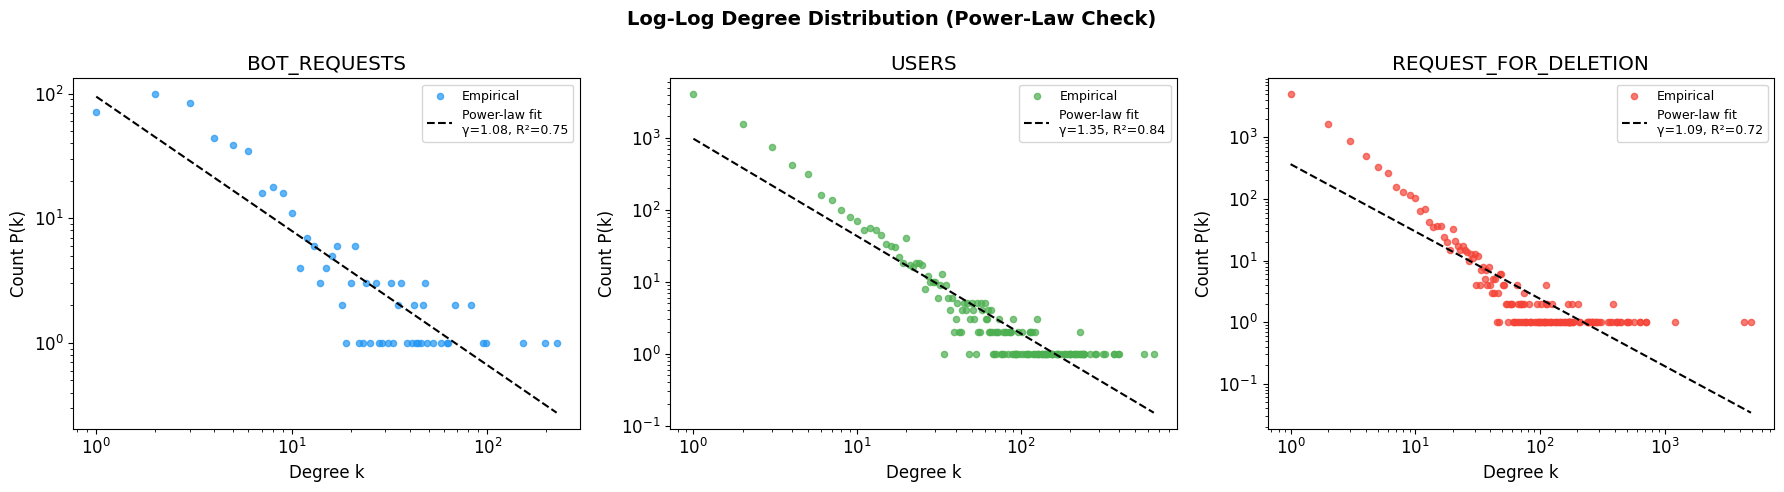

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Log-Log Degree Distribution (Power-Law Check)', fontsize=14, fontweight='bold')

for ax, (name, G) in zip(axes, graphs.items()):
    degrees = np.array([d for _, d in G.degree()])
    degrees = degrees[degrees > 0]
    degree_counts = collections.Counter(degrees)
    x = np.array(sorted(degree_counts.keys()))
    y = np.array([degree_counts[k] for k in x])

    ax.scatter(x, y, color=COLORS[name], alpha=0.7, s=20, label='Empirical')

    # Fitting power law on log-log scale
    log_x = np.log10(x[y > 0])
    log_y = np.log10(y[y > 0])
    if len(log_x) > 2:
        slope, intercept, r, p, se = stats.linregress(log_x, log_y)
        fit_y = 10**(intercept + slope * log_x)
        ax.plot(x[y > 0], fit_y, 'k--', linewidth=1.5, label=f'Power-law fit\nγ={-slope:.2f}, R²={r**2:.2f}')

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_title(name)
    ax.set_xlabel('Degree k')
    ax.set_ylabel('Count P(k)')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('task_b_power_law.png', dpi=150, bbox_inches='tight')
plt.show()

The log-log degree distribution shows a heavy tailed pattern. The linear fit gives γ ≈ 1.1-1.4, which is lower than the typical 2-3 range for scale free networks. This may reflect the approximate nature of OLS fitting on binned degree counts, a stricter maximum likelihood approach would give more precise estimates (Clauset et al., 2009).

### B.3 Top-10 Most Central Nodes (Degree, Betweenness, Closeness)

In [11]:
def centrality_table(G, name, top_n=10):
    username = nx.get_node_attributes(G, 'username')

    # Degree centrality
    deg_c  = nx.degree_centrality(G)

    # For large graphs, computing betweenness on a sample
    if G.number_of_nodes() > 3000:
        bet_c = nx.betweenness_centrality(G, k=500, seed=42)
    else:
        bet_c = nx.betweenness_centrality(G)

    # Closeness on LCC
    lcc = max(nx.connected_components(G), key=len)
    lcc_G = G.subgraph(lcc).copy()
    clo_c = nx.closeness_centrality(lcc_G)

    print(f'\n{name} : Top {top_n} by Degree Centrality ')
    top_deg = sorted(deg_c.items(), key=lambda x: x[1], reverse=True)[:top_n]
    for node, val in top_deg:
        print(f'  {username.get(node, node):<30} degree_centrality={val:.4f}  degree={G.degree(node)}')

    print(f'\n{name} : Top {top_n} by Betweenness Centrality ')
    top_bet = sorted(bet_c.items(), key=lambda x: x[1], reverse=True)[:top_n]
    for node, val in top_bet:
        print(f'  {username.get(node, node):<30} betweenness={val:.4f}')

    print(f'\n{name} : Top {top_n} by Closeness Centrality (LCC) ')
    top_clo = sorted(clo_c.items(), key=lambda x: x[1], reverse=True)[:top_n]
    for node, val in top_clo:
        print(f'  {username.get(node, node):<30} closeness={val:.4f}')

for name, G in graphs.items():
    centrality_table(G, name)


BOT_REQUESTS : Top 10 by Degree Centrality 
  Pasleim                        degree_centrality=0.4102  degree=226
  Jura1                          degree_centrality=0.3593  degree=198
  Matěj Suchánek                 degree_centrality=0.2759  degree=152
  ValterVB                       degree_centrality=0.1779  degree=98
  Pigsonthewing                  degree_centrality=0.1724  degree=95
  Edoderoo                       degree_centrality=0.1488  degree=82
  Multichill                     degree_centrality=0.1488  degree=82
  Ricordisamoa                   degree_centrality=0.1234  degree=68
  Succu                          degree_centrality=0.1234  degree=68
  Sjoerddebruin                  degree_centrality=0.1143  degree=63

BOT_REQUESTS : Top 10 by Betweenness Centrality 
  Pasleim                        betweenness=0.2582
  Jura1                          betweenness=0.2144
  Matěj Suchánek                 betweenness=0.1419
  ValterVB                       betweenness=0.0576
  Ed

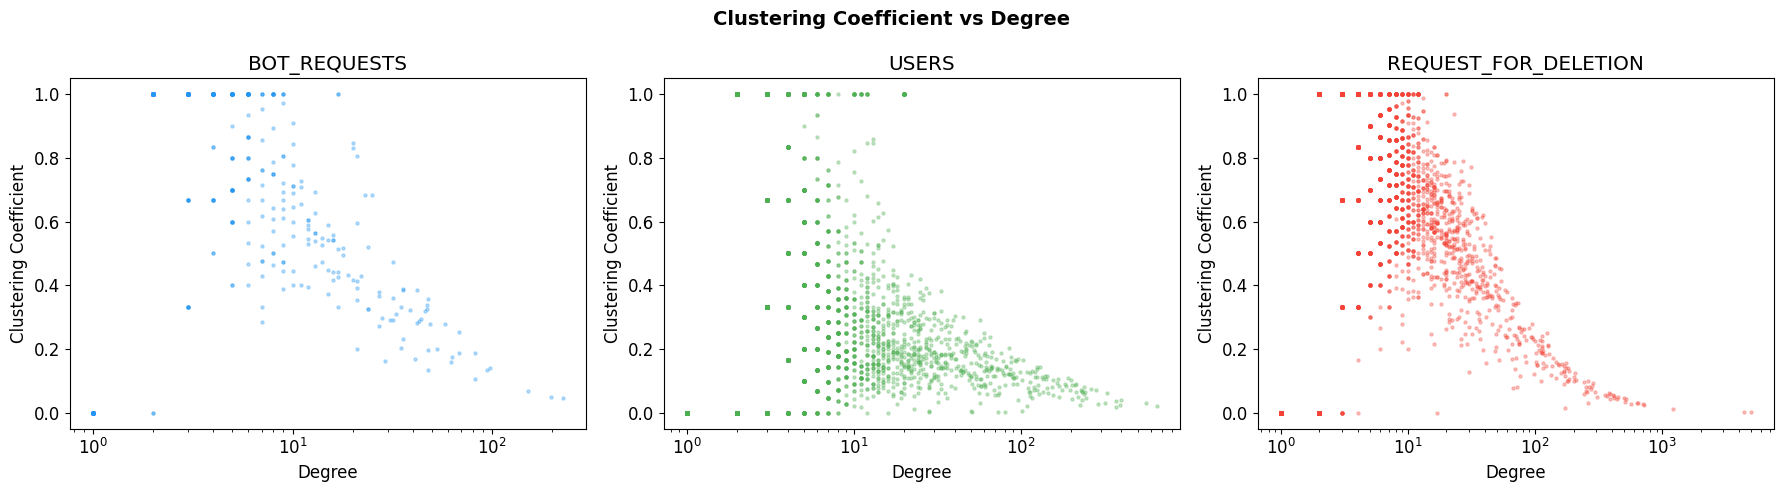

In [12]:
# Clustering vs Degree Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Clustering Coefficient vs Degree', fontsize=14, fontweight='bold')

for ax, (name, G) in zip(axes, graphs.items()):
    clustering = nx.clustering(G)
    degrees    = dict(G.degree())
    x = [degrees[n] for n in G.nodes()]
    y = [clustering[n] for n in G.nodes()]
    ax.scatter(x, y, alpha=0.3, s=5, color=COLORS[name])
    ax.set_xlabel('Degree')
    ax.set_ylabel('Clustering Coefficient')
    ax.set_title(name)
    ax.set_xscale('log')

plt.tight_layout()
plt.savefig('task_b_clustering_vs_degree.png', dpi=150, bbox_inches='tight')
plt.show()

## TASK C : Epidemic Models for Troll Propagation

### C.1 Textual Explanation of Approach

The Wikimedia Foundation selects two random editors daily and checks whether they have been commenting more than usual in the same page-thread indicating a signal of potentially controversial or trolling behaviour. We use the network structure to address two questions.

**1) How plausible is it that the behaviour has NOT yet propagated to neighbours?**

We model propagation using the **SIR (Susceptible-Infected-Recovered)** epidemic framework on the network graph. Each editor is a node in one of three states: Susceptible (S, not yet exposed), Infected (I, currently trolling), or Recovered (R, no longer active). At each discrete time step, an infected editor transmits the behaviour to each susceptible neighbour independently with probability β; infected editors recover with probability γ.

The probability that trolling has not yet spread from an infected editor with degree k to any of their neighbours after one time step is: **P(no spread) = (1 - β)^k**

This decreases rapidly with degree. For example, in BOT_REQUESTS, Editor 1 (BrokenSegue, degree=14) gives P(no spread) = (0.9)^14 = 0.23, meaning there is already a **77% chance** at least one neighbour has been exposed after just one step. For a low-degree editor (degree=1, as seen in REQUEST_FOR_DELETION), P(no spread) = 0.9, the probability of no spread is much higher. This tells the Foundation that **the network structure matters enormously** that means checking only the two initially flagged editors is insufficient when either has a high degree.

**2) Priority list for checking other editors**

We rank all non-infected editors by an **exposure risk score**: *score(v) = Σ_s [ 1/d(s,v) ] × degree(v)*

where the sum is over all infected seed editors s, d(s,v) is the shortest path distance from seed s to node v, and degree(v) reflects the node's capacity to further spread the behaviour. Editors at distance 1 (direct neighbours of infected editors) receive the highest scores.

**The situation differs between one vs. two infected editors:**
- **One infected editor**: the risk spreads outward like a single wavefront. Immediate neighbours (distance=1) are top priority, followed by distance-2 nodes with high degree.
- **Both infected**: two simultaneous wavefronts propagate. Nodes close to both seeds receive compounded risk scores and jump to the top of the list. If the two infected editors are in distant parts of the network, the priority list effectively becomes two separate ranked lists merged by risk. If they are nearby (e.g. distance=2 as in BOT_REQUESTS), their neighbourhoods overlap significantly and the combined risk for shared neighbours is approximately doubled.

The SIR simulations (β=0.1, γ=0.05) show that even a single infected editor in a small world network can infect a large fraction of the community. In BOT_REQUESTS, the average peak infection reached **333 editors (60% of the network)** from a single seed. This underlines the urgency of acting on the priority list quickly.


In [13]:
# SIR Epidemic Simulation 

def sir_simulation(G, seed_nodes, beta=0.1, gamma=0.05, max_steps=50):
    state = {n: 'S' for n in G.nodes()}
    for n in seed_nodes:
        if n in state:
            state[n] = 'I'

    history = []

    for step in range(max_steps):
        S = sum(1 for v in state.values() if v == 'S')
        I = sum(1 for v in state.values() if v == 'I')
        R = sum(1 for v in state.values() if v == 'R')
        history.append((S, I, R))

        if I == 0:
            break

        new_state = dict(state)
        for node in G.nodes():
            if state[node] == 'S':
                # Check if any infected neighbour transmits
                infected_neighbours = sum(1 for nb in G.neighbors(node) if state[nb] == 'I')
                if infected_neighbours > 0:
                    prob_no_infection = (1 - beta) ** infected_neighbours
                    if random.random() > prob_no_infection:
                        new_state[node] = 'I'
            elif state[node] == 'I':
                if random.random() < gamma:
                    new_state[node] = 'R'

        state = new_state

    return history, state

In [14]:
# Priority Ranking Function

def priority_list(G, infected_nodes, top_n=20, both_infected=False):
    username = nx.get_node_attributes(G, 'username')
    degrees  = dict(G.degree())

    # Computing shortest paths from each infected node
    all_distances = {}
    for seed in infected_nodes:
        if seed in G:
            all_distances[seed] = nx.single_source_shortest_path_length(G, seed)

    scored = []
    for node in G.nodes():
        if node in infected_nodes:
            continue

        if both_infected and len(infected_nodes) == 2:
            # Both infected: combining risk from both seeds
            d1 = all_distances.get(infected_nodes[0], {}).get(node, float('inf'))
            d2 = all_distances.get(infected_nodes[1], {}).get(node, float('inf'))
            risk1 = 1/d1 if d1 > 0 and d1 != float('inf') else 0
            risk2 = 1/d2 if d2 > 0 and d2 != float('inf') else 0
            # Two infected sources -> multiplicative exposure model
            score = (risk1 + risk2) * degrees.get(node, 1)
            min_d = min(d1, d2)
        else:
            # Only one infected (or one of two)
            seed = infected_nodes[0]
            d = all_distances.get(seed, {}).get(node, float('inf'))
            score = (1/d if d > 0 and d != float('inf') else 0) * degrees.get(node, 1)
            min_d = d

        scored.append((node, username.get(node, str(node)), score, min_d))

    scored.sort(key=lambda x: x[2], reverse=True)
    return scored[:top_n]

In [15]:
# Run simulations for each network 

def run_task_c(G, name, beta=0.1, gamma=0.05, n_runs=10):
    print(f'\n{'='*60}')
    print(f'TASK C: {name}')
    print(f'{'='*60}')

    username = nx.get_node_attributes(G, 'username')
    nodes    = list(G.nodes())

    # Picking two random editors
    random.seed(42)
    editor1, editor2 = random.sample(nodes, 2)
    print(f'\nRandomly selected editors:')
    print(f'  Editor 1: {username.get(editor1,editor1)} (degree={G.degree(editor1)})')
    print(f'  Editor 2: {username.get(editor2,editor2)} (degree={G.degree(editor2)})')

    # Check if they are in the same component
    try:
        dist = nx.shortest_path_length(G, editor1, editor2)
        print(f'  Shortest path between them: {dist} hops')
    except nx.NetworkXNoPath:
        print('  No path between them (different components)')
        dist = float('inf')

    # Scenario A: Neither is trolling 
    print(f'\n[Scenario A] Neither editor is trolling')
    print(f'  No action needed. No epidemic seed.')

    # Scenario B: One is trolling 
    print(f'\n[Scenario B] Editor 1 is trolling (single infected seed)')
    infected_one = [editor1]

    # Probability that trolling has NOT yet spread to immediate neighbours
    k = G.degree(editor1)
    prob_not_spread_one_step = (1 - beta) ** k
    print(f'  Editor 1 has {k} neighbours.')
    print(f'  P(no spread to ANY neighbour in one step) = (1-β)^k = (1-{beta})^{k} = {prob_not_spread_one_step:.4f}')
    print(f'  → There is a {(1-prob_not_spread_one_step)*100:.1f}% chance trolling has already spread to at least one neighbour.')

    # Run SIR
    histories_one = []
    for _ in range(n_runs):
        h, _ = sir_simulation(G, infected_one, beta=beta, gamma=gamma)
        histories_one.append(h)

    max_len = max(len(h) for h in histories_one)
    avg_I_one = []
    for t in range(max_len):
        vals = [h[t][1] for h in histories_one if t < len(h)]
        avg_I_one.append(np.mean(vals))

    print(f'  Average peak infected (across {n_runs} runs): {max(avg_I_one):.1f} editors')
    print(f'  Average epidemic duration: {len(avg_I_one)} steps')

    # Priority list for single infected
    print(f'\n  Priority list to check next (ONE infected):')
    plist_one = priority_list(G, infected_one, top_n=10, both_infected=False)
    print(f'  {"Rank":<5} {"Username":<30} {"Risk Score":<12} {"Distance"}')
    for rank, (node, uname, score, d) in enumerate(plist_one, 1):
        print(f'  {rank:<5} {uname:<30} {score:<12.4f} {d}')

    # Scenario C: BOTH are trolling 
    print(f'\n[Scenario C] Both editors are trolling (two infected seeds)')
    infected_both = [editor1, editor2]

    k1, k2 = G.degree(editor1), G.degree(editor2)
    print(f'  Editor 1 has {k1} neighbours, Editor 2 has {k2} neighbours.')
    print(f'  With two independent seeds, the epidemic has TWO simultaneous origins.')
    print(f'  P(no spread from Editor 1) = {(1-beta)**k1:.4f}')
    print(f'  P(no spread from Editor 2) = {(1-beta)**k2:.4f}')
    print(f'  P(no spread from EITHER)   = {(1-beta)**k1 * (1-beta)**k2:.4f}')

    histories_both = []
    for _ in range(n_runs):
        h, _ = sir_simulation(G, infected_both, beta=beta, gamma=gamma)
        histories_both.append(h)

    max_len_b = max(len(h) for h in histories_both)
    avg_I_both = []
    for t in range(max_len_b):
        vals = [h[t][1] for h in histories_both if t < len(h)]
        avg_I_both.append(np.mean(vals))

    print(f'  Average peak infected (across {n_runs} runs): {max(avg_I_both):.1f} editors')
    print(f'  Average epidemic duration: {len(avg_I_both)} steps')
    print(f'  Compare to single seed peak: {max(avg_I_one):.1f} → increase factor: {max(avg_I_both)/max(avg_I_one):.2f}x')

    print(f'\n  Priority list to check next (BOTH infected):')
    plist_both = priority_list(G, infected_both, top_n=10, both_infected=True)
    print(f'  {"Rank":<5} {"Username":<30} {"Risk Score":<12} {"Min Distance"}')
    for rank, (node, uname, score, d) in enumerate(plist_both, 1):
        print(f'  {rank:<5} {uname:<30} {score:<12.4f} {d}')

    return histories_one, histories_both, avg_I_one, avg_I_both


results_c = {}
for name, G in graphs.items():
    results_c[name] = run_task_c(G, name, beta=0.1, gamma=0.05, n_runs=10)


TASK C: BOT_REQUESTS

Randomly selected editors:
  Editor 1: BrokenSegue (degree=14)
  Editor 2: 94.234.170.78 (degree=3)
  Shortest path between them: 2 hops

[Scenario A] Neither editor is trolling
  No action needed. No epidemic seed.

[Scenario B] Editor 1 is trolling (single infected seed)
  Editor 1 has 14 neighbours.
  P(no spread to ANY neighbour in one step) = (1-β)^k = (1-0.1)^14 = 0.2288
  → There is a 77.1% chance trolling has already spread to at least one neighbour.
  Average peak infected (across 10 runs): 332.8 editors
  Average epidemic duration: 50 steps

  Priority list to check next (ONE infected):
  Rank  Username                       Risk Score   Distance
  1     Jura1                          198.0000     1
  2     Matěj Suchánek                 152.0000     1
  3     Pasleim                        113.0000     2
  4     Edoderoo                       82.0000      1
  5     ValterVB                       49.0000      2
  6     Vojtěch Dostál                 48.

Seed node: Pasleim (degree=226)


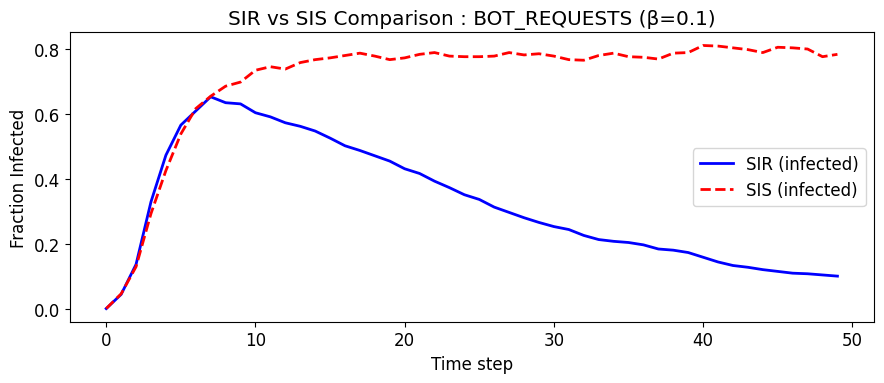

In [16]:
# SIS model for comparison
# In SIS, recovered editors can become susceptible again (no permanent immunity). This is relevant if trolling behaviour can recur after a period of inactivity.

def sis_simulation(G, seed_nodes, beta=0.1, delta=0.05, max_steps=50):
    # delta = recovery rate back to Susceptible (not Removed)
    state = {n: 'S' for n in G.nodes()}
    for n in seed_nodes:
        if n in state:
            state[n] = 'I'
    history = []
    for step in range(max_steps):
        I = sum(1 for v in state.values() if v == 'I')
        history.append(I)
        if I == 0:
            break
        new_state = dict(state)
        for node in G.nodes():
            if state[node] == 'S':
                infected_nb = sum(1 for nb in G.neighbors(node) if state[nb] == 'I')
                if infected_nb > 0:
                    prob_no_inf = (1 - beta) ** infected_nb
                    if random.random() > prob_no_inf:
                        new_state[node] = 'I'
            elif state[node] == 'I':
                # Recover back to S, not R
                if random.random() < delta:
                    new_state[node] = 'S'
        state = new_state
    return history

# Compare SIR vs SIS on BOT_REQUESTS
G_test = graphs['BOT_REQUESTS']
# Using the same editor 1 from run_task_c for fair comparison and picking a high degree node to ensure visible epidemic spread.
degrees_test = dict(G_test.degree())
top_node = max(degrees_test, key=degrees_test.get)
seed = [top_node]
username = nx.get_node_attributes(G_test, 'username')
print(f'Seed node: {username[top_node]} (degree={G_test.degree(top_node)})')
N = G_test.number_of_nodes()

sir_h, _ = sir_simulation(G_test, seed, beta=0.1, gamma=0.05)
sis_h    = sis_simulation(G_test, seed, beta=0.1, delta=0.05)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot([x[1]/N for x in sir_h], 'b-',  lw=2, label='SIR (infected)')
ax.plot([x/N    for x in sis_h], 'r--', lw=2, label='SIS (infected)')
ax.set_xlabel('Time step')
ax.set_ylabel('Fraction Infected')
ax.set_title('SIR vs SIS Comparison : BOT_REQUESTS (β=0.1)')
ax.legend()
plt.tight_layout()
plt.savefig('task_c_sir_vs_sis.png', dpi=150, bbox_inches='tight')
plt.show()

SIR chosen over SIS because:
- Trolling behaviour in practice tends to burn out (editors get banned or disengage) rather than recurring indefinitely.
- SIR recovered state better models permanent removal from the trolling pool via moderation actions.
- SIS would be more appropriate if trolling behaviour is cyclical.

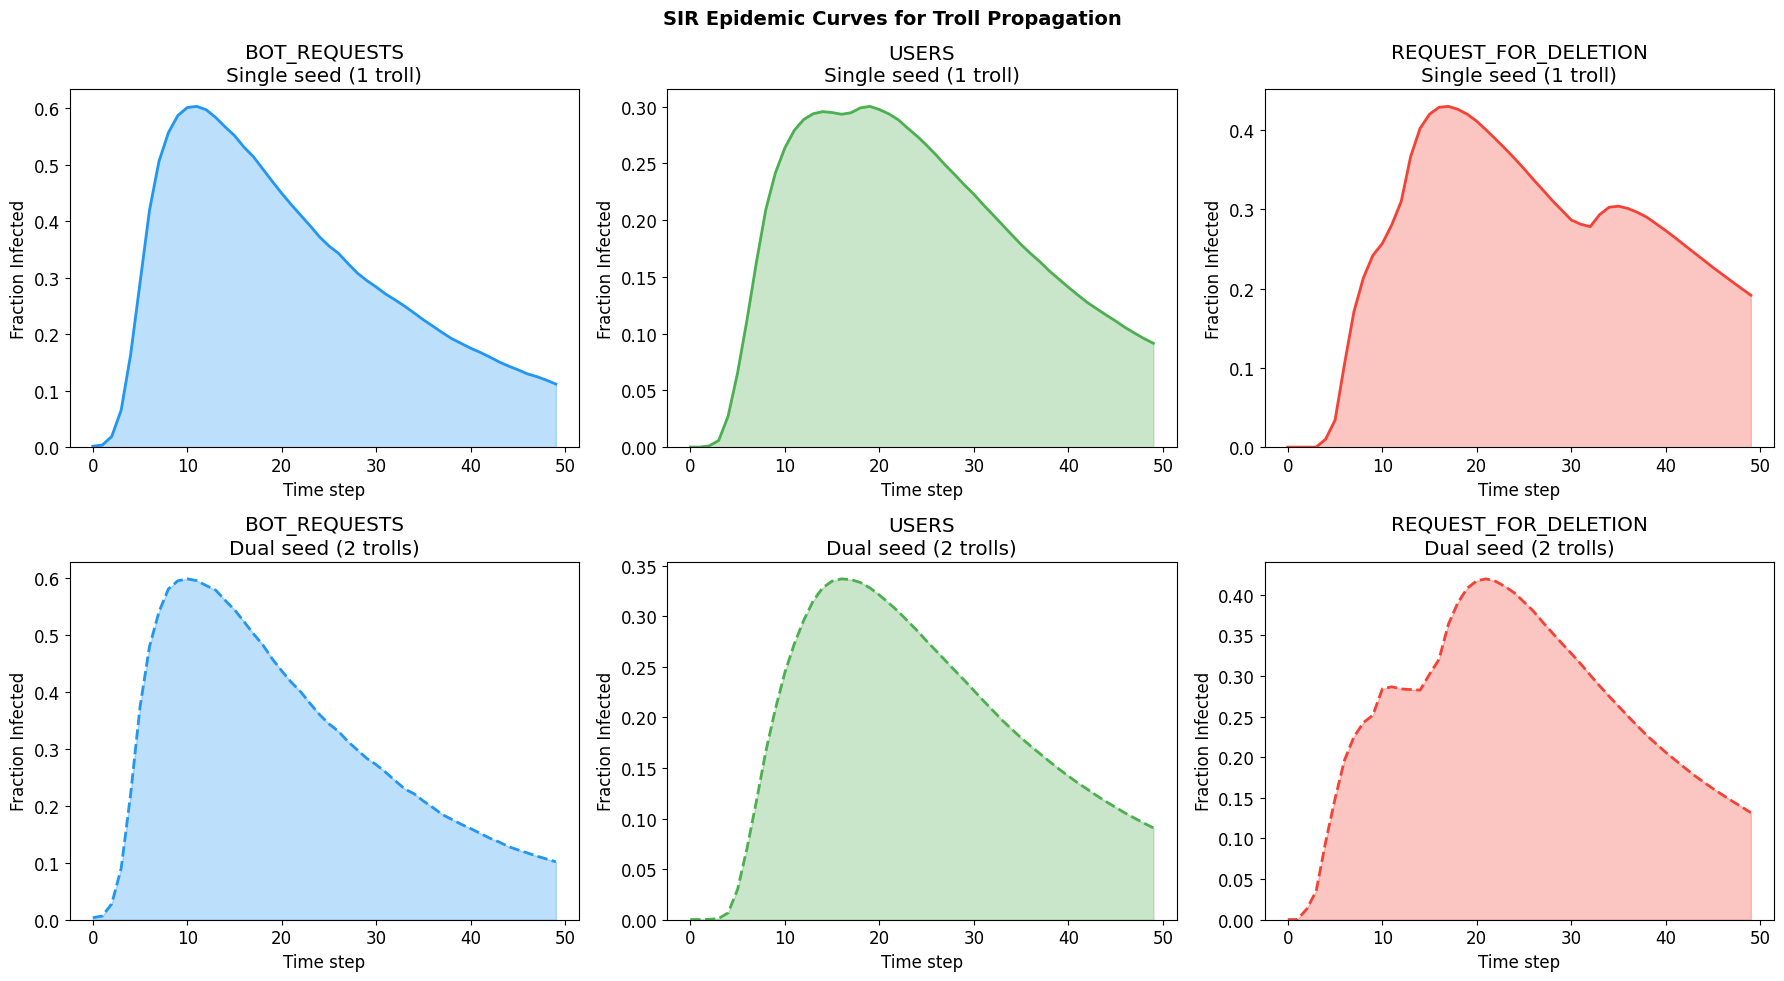

In [17]:
# SIR Curves Visualisation
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('SIR Epidemic Curves for Troll Propagation', fontsize=14, fontweight='bold')

for col, (name, G) in enumerate(graphs.items()):
    h_one, h_both, avg_I_one, avg_I_both = results_c[name]
    N = G.number_of_nodes()

    # Single seed
    ax = axes[0][col]
    ax.plot([i/N for i in avg_I_one], color=COLORS[name], linewidth=2)
    ax.fill_between(range(len(avg_I_one)), [i/N for i in avg_I_one], alpha=0.3, color=COLORS[name])
    ax.set_title(f'{name}\nSingle seed (1 troll)')
    ax.set_xlabel('Time step')
    ax.set_ylabel('Fraction Infected')
    ax.set_ylim(0, None)

    # Both seeds
    ax2 = axes[1][col]
    ax2.plot([i/N for i in avg_I_both], color=COLORS[name], linewidth=2, linestyle='--')
    ax2.fill_between(range(len(avg_I_both)), [i/N for i in avg_I_both], alpha=0.3, color=COLORS[name])
    ax2.set_title(f'{name}\nDual seed (2 trolls)')
    ax2.set_xlabel('Time step')
    ax2.set_ylabel('Fraction Infected')
    ax2.set_ylim(0, None)

plt.tight_layout()
plt.savefig('task_c_sir_curves.png', dpi=150, bbox_inches='tight')
plt.show()

### C.2 Worked Examples: SIR Simulations and Priority Lists

The code below runs the SIR model for each of the three networks under all three scenarios (neither, one, or both infected) and prints the priority list of editors to check. Real output follows each cell.

We then run a sensitivity analysis varying β from 0.01 to 0.3 to show how the network structure determines the epidemic threshold - the value of β above which large scale spread becomes likely.


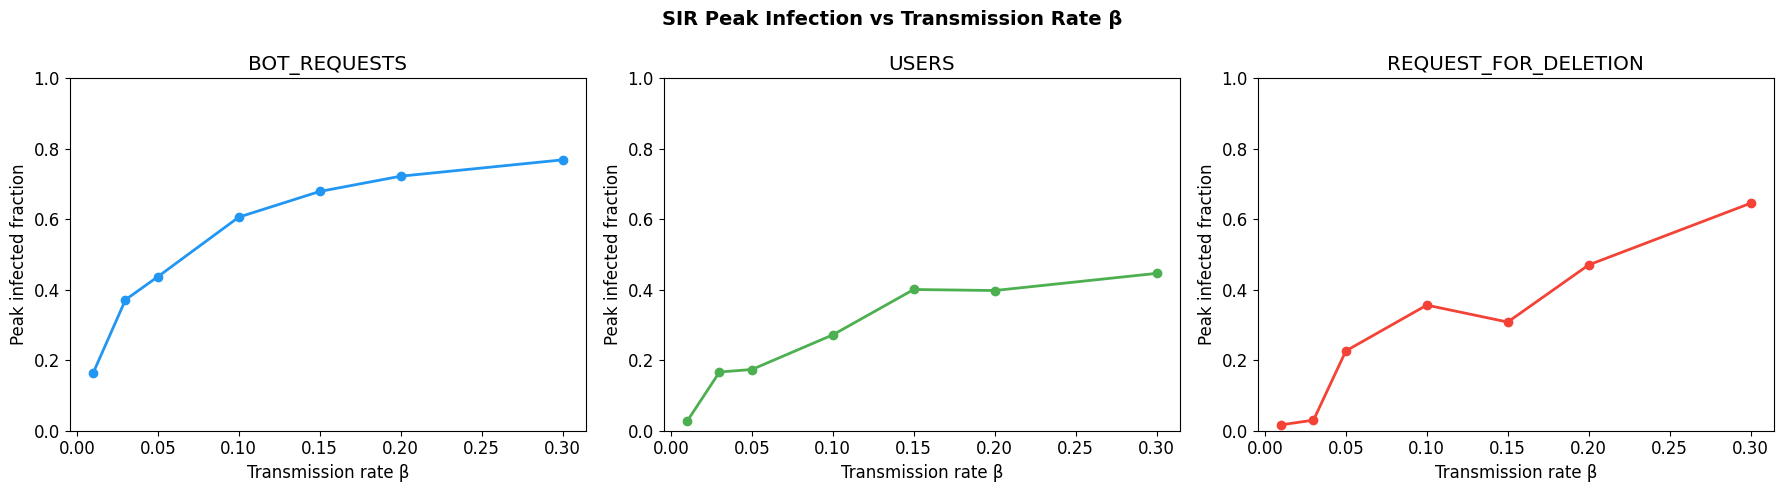

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('SIR Peak Infection vs Transmission Rate β', fontsize=14, fontweight='bold')

betas = [0.01, 0.03, 0.05, 0.1, 0.15, 0.2, 0.3]

for ax, (name, G) in zip(axes, graphs.items()):
    nodes = list(G.nodes())
    random.seed(42)
    seed_node = [random.choice(nodes)]

    peak_fracs = []
    for b in betas:
        run_peaks = []
        for _ in range(10):
            h, _ = sir_simulation(G, seed_node, beta=b, gamma=0.05, max_steps=50)
            run_peaks.append(max(x[1] for x in h) / G.number_of_nodes())
        peak_fracs.append(np.mean(run_peaks))

    ax.plot(betas, peak_fracs, 'o-', color=COLORS[name], linewidth=2)
    ax.set_xlabel('Transmission rate β')
    ax.set_ylabel('Peak infected fraction')
    ax.set_title(name)
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig('task_c_beta_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

## Comparative Discussion Across the Three Networks

All three Wikidata editor networks sit firmly in the **small world** region from the regular/small world/random continuum. In every case, the clustering coefficient far exceeds that of an equivalent Erdős-Rényi random graph (by factors of 42×, 766×, and 690× for BOT_REQUESTS, USERS, and REQUEST_FOR_DELETION respectively), while average path lengths are actually shorter than their random counterparts, yielding Watts-Strogatz σ values of 52, 1373, and 1305. The degree distributions follow a heavy tailed pattern consistent with a scale free topology (power-law exponents γ ≈ 1.1-1.4), indicating that a small number of highly active editors (such as Pasleim with degree 226 in BOT_REQUESTS, or BeneBot* with degree 4355 in REQUEST_FOR_DELETION) act as hubs that hold the community together. This is a familiar pattern in social and collaborative networks (Barabási & Albert, 1999): editors who participate in many discussions become bridges between otherwise disconnected groups. The negative degree assortativity across all three networks (-0.15 to -0.28) confirms that these hubs primarily connect to lower-degree peripheral users rather than to each other, which acts as a structural buffer slowing epidemic spread.

The three networks differ meaningfully in scale and fragmentation. BOT_REQUESTS (small, 552 nodes) shows the highest clustering (C = 0.66) and the lowest heterogeneity (σ/μ = 2.12), reflecting a highly connected technical sub-community with repeated interaction among the same core editors. USERS (medium, 11,387 nodes) has the highest fragmentation, only 68% of nodes belong to the largest connected component, compared to 94% and 99% for the other two because user talk pages are highly localised meaning most users interact only within their own personal talk page threads, creating many small isolated clusters. REQUEST_FOR_DELETION (large, 9,935 nodes) exhibits the highest degree heterogeneity (σ/μ = 10.69) and the largest max degree (4940), driven by automated bots and a small set of extremely prolific human reviewers who participate in nearly every deletion discussion. The choice to define edges by co-commenting in the same (page, thread) pair rather than explicit reply chains likely over-estimates connectivity, particularly in large threads where users may never directly address each other. A stricter edge definition would produce sparser networks with longer path lengths, potentially weakening the small world signal, especially in the USERS network where threads tend to be short and bilateral.


In [19]:
# Final Summary Table
print('FINAL SUMMARY')
print('\nNetwork Metrics ')
print(metrics_df.T.to_string())
print('\nSmall World Comparison ')
print(rg_df.T.to_string())

FINAL SUMMARY

Network Metrics 
Dataset               BOT_REQUESTS          USERS REQUEST_FOR_DELETION
N (nodes)                      552          11387                 9935
E (edges)                     2425          24755                33497
Density                   0.015946       0.000382             0.000679
Avg Degree                   8.786          4.348                6.743
Max Degree                     226            649                 4940
Degree Std                  18.623         18.808               72.061
Heterogeneity (σ/μ)           2.12          4.326               10.686
Avg Clustering              0.6576         0.1834                0.392
Avg Path Length (LCC)        2.603          3.654                2.697
Diameter (LCC)                   6  N/A (sampled)        N/A (sampled)
Num Components                  29           3255                   57
LCC Fraction                0.9402         0.6827               0.9935
Assortativity              -0.2785         -0